# Modelling Solid State batteries

Before leaving
* upload a few datasets onto onedrive
At home:
* figure out fft, cwt, and tmm in new sql format
* figure out how to handle timed data lik the pressure sensor
* make SS figure

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib tk

import sys
sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonicTesting/')
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonic_ml/src/')

import ultrasonic_ml.models.tmm_np as tmm
import pickleJar as pj
import numpy as np

import pandas as pd

import scipy
from tqdm import tqdm

tk max_dimensions: 15.39 x 9.96


## Experimental setup:

<img src="ss_stack.png" width="400"/>

- Transducers: 2.25 MHz (longitudinal) ​
- Couplant: nitrile, NBR, and acrylonitrile butadiene (BNR – McMaster Carr). Electronically insulating ​
- Repeat pulse collecting every 30 seconds ​
- Testing inside a temperature chamber ​
- Assumptions: ​
    - Using rule of mixtures for anode ​
    - Using rule of mixtures for cathode​
    - E and density of electrolyte, carbon, binder, current collectors does not change during cycling ​
    - Homogeneous, isotropic, linear elastic, and continuous ​
    - Interface between the different components have the same properties as the bulk ​v

Fatima's pptx: [Ford - Dec 2025](https://drexel0.sharepoint.com/:p:/r/sites/ChangLab/_layouts/15/Doc.aspx?sourcedoc=%7B84F84037-9208-4FB0-9E6E-A4A7BDC5C363%7D&file=Ford%20-%20Dec%202025.pptx&action=edit&mobileredirect=true)
- look into citations for Si, NMC

My pptx: [2026-7-16-TRINA](https://drexel0.sharepoint.com/:p:/r/sites/ChangLab/Shared%20Documents/General/Individual/Xinqiao%20Zhang/Slides/2026-7_16_TRINA.pptx?d=wa4f000b988c54e699eb874b4affb6f58&csf=1&web=1&e=MXSGSB)

LSPCl
- [MSE supplies](https://www.msesupplies.com/products/ampcera-argyrodite-li6ps5cl-sulfide-solid-electrolyte-ultra-fine-powder-d50-2-3-um?utm_source=google&utm_medium=cpc&utm_campaign=21503213167&utm_term=&gad_source=1&gad_campaignid=21503213167&gbraid=0AAAAADd9Nn_nx54-KEefwCwcDvmv6-Ipl&gclid=CjwKCAjw1vXTBhB-EiwAEKr_k_XbFb6dYrHT4CA9Vyk4OOaccTWYdjo4u5EG7bynFVBkpj9XI-UP-hoCVTgQAvD_BwE&variant=23379283902522)
- [First-Principles Investigation of Mechanical Properties and Anisotropy of Argyrodite Li6PS5Cl Crystal Electrolytes](https://pubs.acs.org/jpccck/article/129/39/17882/3740509/First-Principles-Investigation-of-Mechanical)


couplant:
- [Oil-Resistant Buna-N Rubber Sheet, 12" x 12", 3/32" Thick, 50A Durometer](https://www.mcmaster.com/products/nitrile-rubber-sheets/thickness~3-32/width~12/width~1-ft/backing-type~plain/length~12/length~1-ft/hardness~durometer-50a/?s=nitrile-rubber-sheets)
- [Stability-Constrained Hyperelastic Calibration of Nitrile Butadiene Rubber Using Multi-Mode Experiments, Genetic Algorithm Optimization, and Finite Element Analysis
](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=7347049)
- 

Steel
- [T300 Stainless Steel](https://www.matweb.com/search/DataSheet.aspx?MatGUID=7a87941825a3463eaba7979c4333721f)

Copper


Calculating mechanical properties:
- [Convert Elastic Modulus Constants (Shear, Young’s, Bulk)](https://www.mydatabook.org/solid-mechanics/convert-elastic-modulus-constants-shear-youngs-bulk/): starting point. Go find textbook
- NOTE: usually you need to use bulk modulus for speed of sound calculations, however, in thin films and fibers where there is freedom to expand, elastic modulus in the direction of longitudinal sound wave can be used. look at the old article. [Young's Modulus of Elasticity of Fibers and Films by Sound Velocity Measurements](https://pubs.aip.org/asa/jasa/article-abstract/16/2/113/646765/Young-s-Modulus-of-Elasticity-of-Fibers-and-Films?redirectedFrom=fulltext)

## Parameters calculations:
TODO: Eventually, we wnat in this format, w conversion functions for better readability:
* $c$ — sound velocity [m/s]
* $ρ$ — density [kg/m³]
* $Z = ρ·c$ — acoustic impedance [MRayl / GRayl, N*s/m^3]
* $E= c^2 * ρ$ - elastic modulus (but others can be used interchangeably? in the case of thin films and fibers)
    * $K = c^2 * ρ$ — bulk modulus [GPa]
    * $E = 3K(1 - 2ν)$ - elastic modulus [GPa]
    * $ν$ - Poisson's ratio
* d — thickness [µm]
* n — number of layers of that component in the original cell

For now, just use SI units so its less confusing

In [7]:
params = tmm.params

# tmm

## theory: normal acoustic propagation/ reflection in layered stack
- Feiler, S., Gold, L., Hartmann, S., & Giffin, G. A. (2025). Modeling acoustic attenuation, sound velocity and wave propagation in lithium‐ion batteries via a transfer matrix. Batteries & Supercaps, 8(3), e202400478.
- Byrnes, S. J. (2016). Multilayer optical calculations. arXiv preprint arXiv:1603.02720.
- [to read- tmm for extimating dispersion](https://docs.lib.purdue.edu/cgi/viewcontent.cgi?article=1054&context=herrick)

Using modified notation from Feiler paper for clarity.

- Acoustic waveform $\psi_i$ enters a stack of materials $M_n$. Here, layer 0 and 4 are coupled to the transducer and we assume there is no reflective interface.
    $$\psi_i \rightarrow  M_0 | M_1 | M_2 | M_3 | M_4 $$

    - $P_{M_n}$ is the propagation matrix through material $M_n$ 
        $$
        P_{M_n} =
        \begin{bmatrix} 
            e^{(ik_{M_n} - \alpha_{M_n}) d_{M_n}} & 0 \\ 
            0 &  e^{-(ik_{M_n} - \alpha_{M_n}) d_{M_n}} 
        \end{bmatrix}
        $$
        - $d_{M_n}$ is the layer thickness
        - $\alpha_{M_n}$ is the attenuation coefficient of medium
        - ${c_{M_n}}$ is the speed of sound through the medium
        - $k_{M_n}$ is the wavenumber defined as: $$k_{M_n} = \frac{2\pi}{\lambda} =\frac{2\pi}{c_{M_n}}$$
    - $D_{M_n,M_m}$ is the interface matrix while travelling from $M_n$ to $M_m$
        $$
        D_{M_n,M_m} = \frac{1}{t_{M_n,M_m}}
        \begin{bmatrix} 
            1 & r_{M_n,M_m} \\ r_{M_n,M_m} &  1 
        \end{bmatrix}
        $$
        - $r_{M_n,M_m}$ is the reflection coefficient travelling from $M_n$ to $M_m$, defined as: 
            $$r_{M_n,M_m} = \frac{Z_{M_m} - Z_{M_n}}{Z_{M_n} + Z_{M_m}}$$
        - $t_{M_n,M_m}$ is the transmission coefficient travelling from $M_n$ to $M_m$, defined as:
            $$t_{M_n,M_m} = \frac{2Z_{M_m}}{Z_{M_n} + Z_{M_m}}$$
        - $Z_{M_n}$ is the acoustic impedance defined as: $Z_{M_n} = \rho_{M_i}c_{M_i}$

- The full stack would be constructed as:
    $$
    \begin{bmatrix} \psi_{i,r} \\ \psi_{i,l} \end{bmatrix}
    =P_{M_0}D_{M_0,M_1} P_{M_1}D_{M_1,M_2} P_{M_2}D_{M_2,M_3} P_{M_3}D_{M_3,M_4} P_{M_4}
    \begin{bmatrix} \psi_{f,r} \\ \psi_{f,l} \end{bmatrix}
    $$
    - **Boundary conditions:**
        - $\psi_{i,r}$ is our input wave, as a numpy array. 
        - $\psi_{i,l}$ is unknown. This represents our reflected wave
        - $\psi_{f,r}$ is unknown. This represents our transmitted wave
        - $\psi_{f,l}$ is 0. This is under the assumption that the last layer extends infinitely. 
            - This might not be a good assumption. We may need the acoustic properties of the clamp or transducers to use as the last layer if they contribute to the waveform significantly.
            - Alternatively, we can have a material at the end of the stack the guides the pulse away from the sample. Like an angled block. 

- The final waveform is related to the initial through the transfer matrix 
    $$\psi_i = T \psi_f$$
    $$
    \begin{bmatrix} \psi_{i,r} \\ \psi_{i,l} \end{bmatrix}
    =
    \begin{bmatrix} T_{11} & T_{12} \\ T_{21} & T_{22} \end{bmatrix}
    \begin{bmatrix} \psi_{f,r} \\ \psi_{f,l} \end{bmatrix}
    $$

- $(\psi_{f,r},\psi_{f,l})$ are the final right and left moving waveforms, and  $(\psi_{i,r},\psi_{i,l})$ are the initial.

- $T$ is the transfer matrix constructed from multiplying the propagation and interfaces together. We can now solve the system of equations
    $$
    \begin{bmatrix} \psi_{i,r} \\ \psi_{i,l} \end{bmatrix}
    = \begin{bmatrix} T_{11} & T_{12} \\ T_{12} & T_{22} \end{bmatrix}
    \begin{bmatrix} \psi_{f,r} \\ \psi_{f,l} \end{bmatrix}
    $$
    - Transmission, where the transmission coefficient can be expressed as $T(k) = 1/T_{11}$: 
        $$\psi_{f,r} = \frac{1}{T_{11}} \psi_{i,r}$$
    - Reflection, where the reflection coefficient can be expressed as  $R(k) = T_{12}/T_{11}$: 
        $$\psi_{i,l} = \frac{T_{12}}{T_{11}} \psi_{i,r}$$

- If your input signal contains multiple frequencies (such as our morlet), you need to calculate the transfer matrix at every frequency since the behavior depends on the wavenumber $k=2\pi f/c$:
    - take fft of morlet input
    - calculate transfer matrix $T$ at every frequency. If this is too expensive, we can threshold which bins to use
    - calculate $(\psi_{f,r}, \psi_{i,l})$ in frequency domain and apply ifft to get back to time domain.

- when using FFT transform, there will be signal at both $(\pm f)$.
    - $T(-f) = T(f)^*$ because both the propagation and interface matrices are symmetric. (ie $P_{M_n}(-f) = P_{M_n}(f)^*$ and $D_{M_n,M_m}$ is not frequency dependent)

## Construct stack

In [8]:
import ultrasonic_ml.models.tmm_np as tmm
import scipy.signal as signal

In [9]:
n = 1
layer_list = ['Cu', 'Si', "Li_6 P S_5 Cl", "Li Ni_0.6 Mn_0.2 Co_0.2 O_2"] # just trying with one layer of battery rn

stack = [
    # 'Buna-N 50A',
    'Steel_bottom',
] + layer_list * n + [
    'Steel_top',
    # 'Buna-N 50A',
]

layers_df = tmm.construct_stack_df(stack)
tmm.style_stack_df(layers_df)

,name,density,E,thickness,attenuation,sound_speed,Z,wavelength,name_mpl
0,Steel_bottom,7.85e+03,1.95e+11,2.48e-02,0.00e+00,4.98e+03,3.91e+07,2.22e-03,Steel_bottom
1,Cu,8.96e+03,1.10e+11,1.00e-02,0.00e+00,3.50e+03,3.14e+07,1.56e-03,Cu
2,Si,2.30e+03,1.51e+11,5.00e-03,0.00e+00,8.11e+03,1.86e+07,3.60e-03,$\mathrm{Si}$
3,Li_6 P S_5 Cl,1.64e+03,2.74e+10,1.00e-02,0.00e+00,4.09e+03,6.70e+06,1.82e-03,$\mathrm{Li_{6}PS_{5}Cl}$
4,Li Ni_0.6 Mn_0.2 Co_0.2 O_2,4.76e+03,1.70e+11,5.00e-03,0.00e+00,5.98e+03,2.84e+07,2.66e-03,$\mathrm{LiNi_{0.6}Mn_{0.2}Co_{0.2}O_{2}}$
5,Steel_top,7.85e+03,1.95e+11,4.04e-02,0.00e+00,4.98e+03,3.91e+07,2.22e-03,Steel_top


In [10]:
# rename some stuff if you want to make the plots look nicer
layers_df.loc[[0,5],'name_mpl'] = ['Steel','Steel']
# layers_df.loc[[0,7],'name_mpl'] = ['Coupl.','Coupl.']
layers_df.loc[4,'name_mpl'] = ['NMC']
layers_df.loc[3,'name_mpl'] = ['LPSCl']

In [11]:
tmm.style_stack_df(layers_df)

,name,density,E,thickness,attenuation,sound_speed,Z,wavelength,name_mpl
0,Steel_bottom,7.85e+03,1.95e+11,2.48e-02,0.00e+00,4.98e+03,3.91e+07,2.22e-03,Steel
1,Cu,8.96e+03,1.10e+11,1.00e-02,0.00e+00,3.50e+03,3.14e+07,1.56e-03,Cu
2,Si,2.30e+03,1.51e+11,5.00e-03,0.00e+00,8.11e+03,1.86e+07,3.60e-03,$\mathrm{Si}$
3,Li_6 P S_5 Cl,1.64e+03,2.74e+10,1.00e-02,0.00e+00,4.09e+03,6.70e+06,1.82e-03,LPSCl
4,Li Ni_0.6 Mn_0.2 Co_0.2 O_2,4.76e+03,1.70e+11,5.00e-03,0.00e+00,5.98e+03,2.84e+07,2.66e-03,NMC
5,Steel_top,7.85e+03,1.95e+11,4.04e-02,0.00e+00,4.98e+03,3.91e+07,2.22e-03,Steel


### Look at transmitted and reflected waveform after each interface
- Transmitted: $\psi_{f,r} = \frac{1}{T_{11}} \psi_{i,r}$ 
- Reflected: $\psi_{i,l} = \frac{T_{12}}{T_{11}} \psi_{i,r}$


In [20]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-1000,20000-1000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))

### 1 layer

In [ ]:
current_layers_df = layers_df.iloc[:1]
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form   
transmitted_waveform = np.real(tmm.propagate_waveform(input_waveform, dt, layers)) 
transmitted_envelope = abs(scipy.signal.hilbert(transmitted_waveform))
reflected_waveform = np.real(tmm.reflect_waveform(input_waveform, dt, layers))
reflected_envelope = abs(scipy.signal.hilbert(reflected_waveform))

ValueError: x must be real.

##### Take a look at the time delays in the transmitted waveform. 
- The first peak should correspond to the theoretical transmitted time delay through the layers. 
- There is no reflection yet.
- Differences may be attributed to the time resolution, or numerical errors


In [123]:
import ultrasonic_ml.models.tmm_np as tmm

In [124]:
# dfs style algorithm to generate all valid reflection and transmission paths up to a specified order
# first and last are not included in layer list because there are no interfaces
paths = tmm.generate_acoustic_paths(num_layers=len(current_layers_df), max_order=5)
tmm.print_paths(paths, return_paths=False)

Transmission: 0 | Path: 0 -> exit


In [125]:
tmm.compare_peak_times(t, layers_df, 
                       transmitted_envelope, reflected_envelope, 
                       paths)

Transmitted tof: (TMM peaks,	theoretical)
	0:	(2.2200e-06,	2.2194e-06)
Reflected tof: (TMM peaks,	theoretical)


In [126]:
tmm.plot_path_waveforms_theoretical_v_tmm_time_delays(layers_df, paths, t, 
                                          input_waveform, transmitted_waveform, reflected_waveform, 
                                          input_envelope, transmitted_envelope, reflected_envelope, 
                                          layers=list(current_layers_df.index))

/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonic_ml/src/ultrasonic_ml/models/tmm_np.py:31: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  # split into (Element, subscript) tokens, ignoring spaces


##### Take a look at the amplitudes of the waveforms. We are assuming 0 attenuation at the moment. 
- ([wiki article](https://en.wikipedia.org/wiki/Transfer-matrix_method_(optics)#Acoustic_waves)), ([using impedances](https://www.nde-ed.org/Physics/Waves/reflectiontransmission.xhtml)) 
    - NOTE: Need to double check why there is mismatch in the powers. Is it because of the fft/ ifft? Or other mistake? Does the input need an imaginary component?
- Total power $(P)$ must be conserved: 
    $$ P_{in} = P_{t} + P_{r} \text{\ where \ } P_{t} = \left\lvert \frac{1}{T_{11}} \right\rvert ^2 \text{\ and \ } P_{r} = \left\lvert \frac{T_{21}}{T_{11}} \right\rvert ^2 $$
- aka:
    $$1 = \left\lvert R \right\rvert ^2 + \left\lvert T \right\rvert ^2 = P_{r}/P_{in} + P_{t}/P_{in}$$

In [27]:
tmm.compare_tmm_waveform_coefficients(input_waveform, transmitted_waveform, reflected_waveform, layers, dt)

,calculate from,transmission coefficient,reflection coefficient,total
0,TMM,1.0000,0.0000,1.0000
1,Waveforms,1.0000,0.0000,1.0000


### 2 layers + sanity checks

In [30]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-2000,10000-2000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))

In [31]:
current_layers_df = layers_df.iloc[:2]
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form
    
transmitted_waveform = tmm.propagate_waveform(input_waveform, dt, layers) 
transmitted_envelope = abs(signal.hilbert(transmitted_waveform))

reflected_waveform = tmm.reflect_waveform(input_waveform, dt, layers)
reflected_envelope = abs(signal.hilbert(reflected_waveform))

##### Take a look at the time delays in the transmitted waveform. 

In [32]:
# dfs style algorithm to generate all valid reflection and transmission paths up to a specified order
# first and last are not included in layer list because there are no interfaces
paths = tmm.generate_acoustic_paths(num_layers=2, max_order=4)
tmm.print_paths(paths, return_paths=False)

Transmission: 0 | Path: 0 -> 1 -> exit
Reflection: 1 | Path: 0 -> R(0|1) -> 0 -> exit


In [33]:
tmm.compare_peak_times(t, layers_df, 
                       transmitted_envelope, reflected_envelope, 
                       paths)

Transmitted tof: (TMM peaks,	theoretical)
	0:	(7.1940e-06,	7.1933e-06)
Reflected tof: (TMM peaks,	theoretical)
	0:	(4.4380e-06,	4.4388e-06)


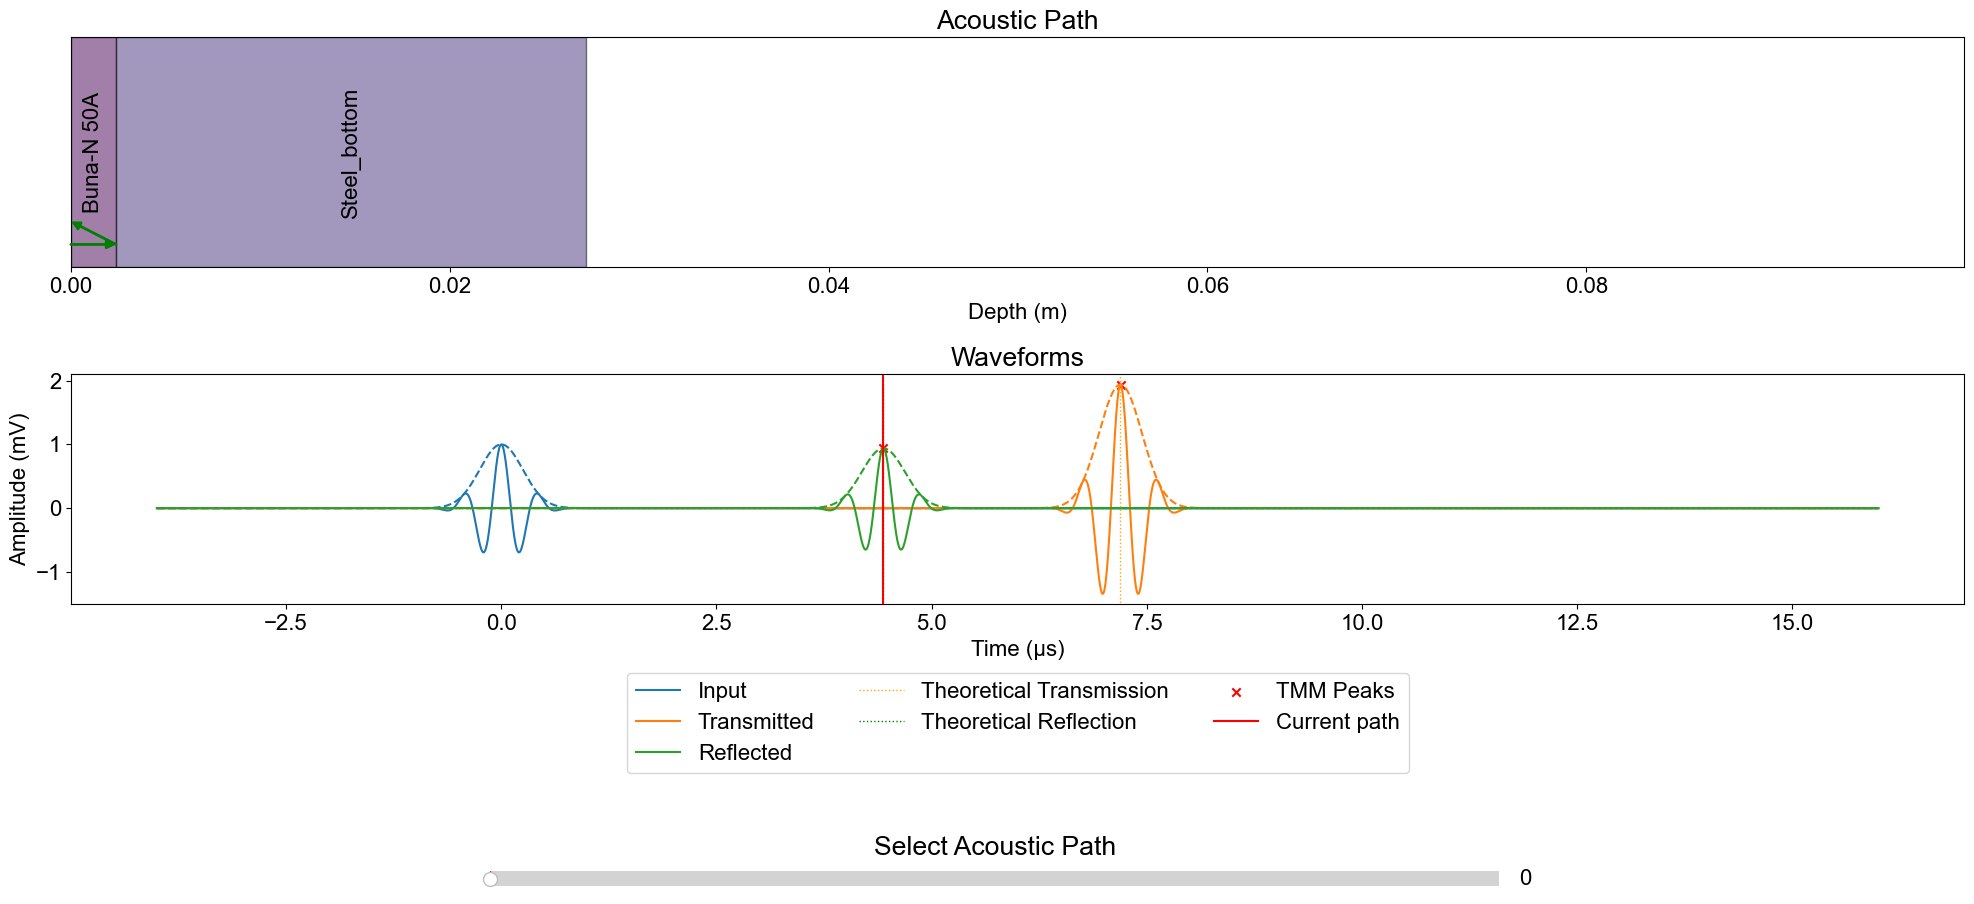

In [34]:
tmm.plot_path_waveforms_theoretical_v_tmm_time_delays(layers_df, paths, t, 
                                          input_waveform, transmitted_waveform, reflected_waveform, 
                                          input_envelope, transmitted_envelope, reflected_envelope,
                                          layers=list(current_layers_df.index))

##### Take a look at the amplitudes of the waveforms. We are assuming 0 attenuation at the moment. 

In [35]:
tmm.compare_tmm_waveform_coefficients(input_waveform, transmitted_waveform, reflected_waveform, layers, dt)

,calculate from,transmission coefficient,reflection coefficient,total
0,TMM,3.7550,0.8794,4.6344
1,Waveforms,3.7550,0.8794,4.6344


### 3 layers + sanity checks

In [36]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-2000,20000+2000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))

In [37]:
current_layers_df = layers_df.iloc[:3]
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form
    
transmitted_waveform = tmm.propagate_waveform(input_waveform, dt, layers) 
transmitted_envelope = abs(signal.hilbert(transmitted_waveform))

reflected_waveform = tmm.reflect_waveform(input_waveform, dt, layers)
reflected_envelope = abs(signal.hilbert(reflected_waveform))

##### Take a look at the time delays in the transmitted waveform. 


In [38]:
# dfs style algorithm to generate all valid reflection and transmission paths up to a specified order
# first and last are not included in layer list because there are no interfaces
# Odd orders yield more reflection paths, even orders are transmission paths
paths = tmm.generate_acoustic_paths(num_layers=3, max_order=5)
paths.sort(key=lambda x: tmm.theoretical_path_time(x, layers_df))
tmm.print_paths(paths, return_paths=False)

Transmission: 0 | Path: 0 -> 1 -> 2 -> exit
Transmission: 2 | Path: 0 -> 1 -> R(1|2) -> 1 -> R(0|1) -> 1 -> 2 -> exit
Transmission: 4 | Path: 0 -> 1 -> R(1|2) -> 1 -> R(0|1) -> 1 -> R(1|2) -> 1 -> R(0|1) -> 1 -> 2 -> exit
Reflection: 1 | Path: 0 -> R(0|1) -> 0 -> exit
Reflection: 1 | Path: 0 -> 1 -> R(1|2) -> 1 -> 0 -> exit
Reflection: 3 | Path: 0 -> 1 -> R(1|2) -> 1 -> R(0|1) -> 1 -> R(1|2) -> 1 -> 0 -> exit
Reflection: 5 | Path: 0 -> 1 -> R(1|2) -> 1 -> R(0|1) -> 1 -> R(1|2) -> 1 -> R(0|1) -> 1 -> R(1|2) -> 1 -> 0 -> exit


In [39]:
tmm.compare_peak_times(t, layers_df, 
                       transmitted_envelope, reflected_envelope, 
                       paths)

Transmitted tof: (TMM peaks,	theoretical)
	0:	(1.0048e-05,	1.0047e-05)
	1:	(1.9996e-05,	1.9995e-05)
	2:	(2.9944e-05,	2.9943e-05)
Reflected tof: (TMM peaks,	theoretical)
	0:	(4.4380e-06,	4.4388e-06)
	1:	(1.4384e-05,	1.4387e-05)


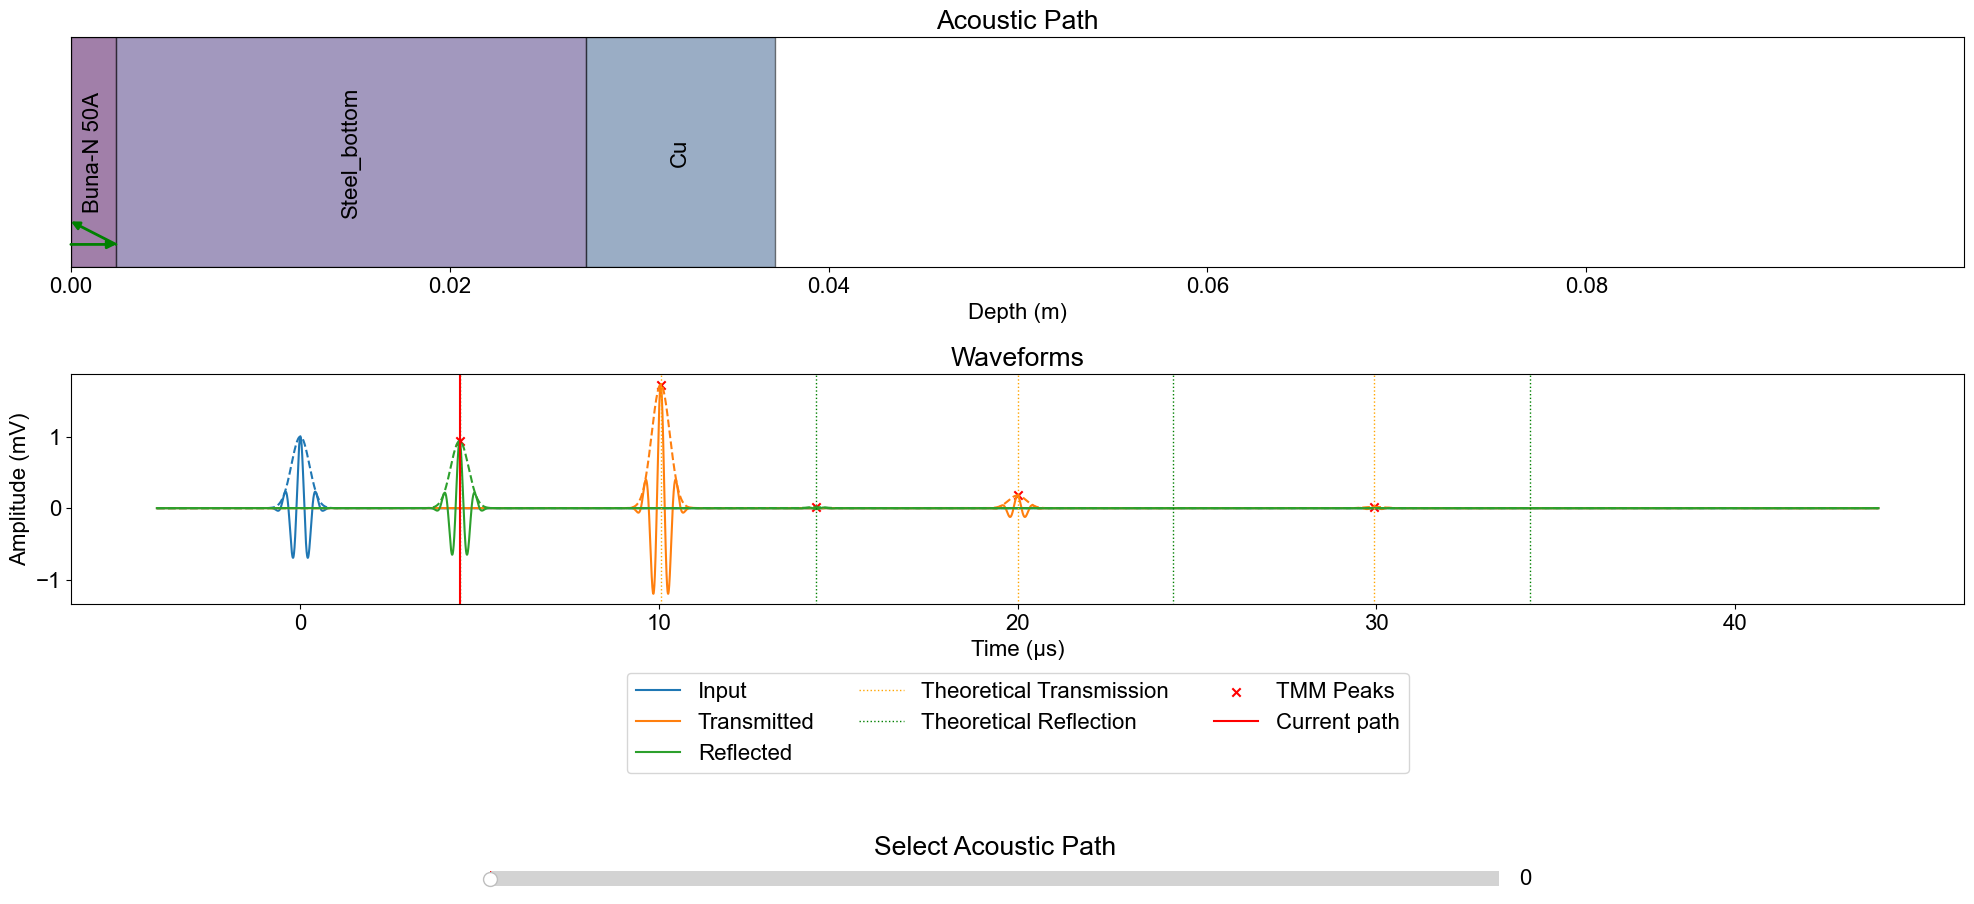

In [40]:
tmm.plot_path_waveforms_theoretical_v_tmm_time_delays(layers_df, paths, t, 
                                          input_waveform, transmitted_waveform, reflected_waveform, 
                                          input_envelope, transmitted_envelope, reflected_envelope,
                                          layers=list(current_layers_df.index))

##### Take a look at the amplitudes of the waveforms. We are assuming 0 attenuation at the moment. 

In [41]:
tmm.compare_tmm_waveform_coefficients(input_waveform, transmitted_waveform, reflected_waveform, layers, dt)

,calculate from,transmission coefficient,reflection coefficient,total
0,TMM,3.0087,0.8796,3.8883
1,Waveforms,3.0086,0.8796,3.8882


### 4 layers (20000 samples)

In [46]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-2000,20000+2000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))

In [47]:
current_layers_df = layers_df.iloc[:4]
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form
    
transmitted_waveform = tmm.propagate_waveform(input_waveform, dt, layers) 
transmitted_envelope = abs(signal.hilbert(transmitted_waveform))

reflected_waveform = tmm.reflect_waveform(input_waveform, dt, layers)
reflected_envelope = abs(signal.hilbert(reflected_waveform))

##### Take a look at the time delays in the transmitted waveform. 

In [48]:
# dfs style algorithm to generate all valid reflection and transmission paths up to a specified order
# first and last are not included in layer list because there are no interfaces
# Odd orders yield more reflection paths, even orders are transmission paths
paths = tmm.generate_acoustic_paths(num_layers=len(list(current_layers_df.index)), max_order=5)
paths.sort(key=lambda x: tmm.theoretical_path_time(x, layers_df))

In [53]:
# tmm.print_paths(paths, return_paths=False)

In [54]:
tmm.compare_peak_times(t, layers_df, 
                       transmitted_envelope, reflected_envelope, 
                       paths)

Transmitted tof: (TMM peaks,	theoretical)
	0:	(3.9200e-06,	1.0664e-05)
	1:	(1.0664e-05,	1.6372e-05)
	2:	(1.6370e-05,	2.0612e-05)
	3:	(2.0612e-05,	2.2080e-05)
	4:	(2.6320e-05,	2.6320e-05)
	5:	(3.0558e-05,	3.0560e-05)
	6:	(3.2026e-05,	3.2028e-05)
	7:	(3.6268e-05,	3.6268e-05)
	8:	(4.1976e-05,	4.1976e-05)
Reflected tof: (TMM peaks,	theoretical)
	0:	(4.4380e-06,	4.4388e-06)
	1:	(1.4384e-05,	1.4387e-05)
	2:	(2.0094e-05,	2.0095e-05)


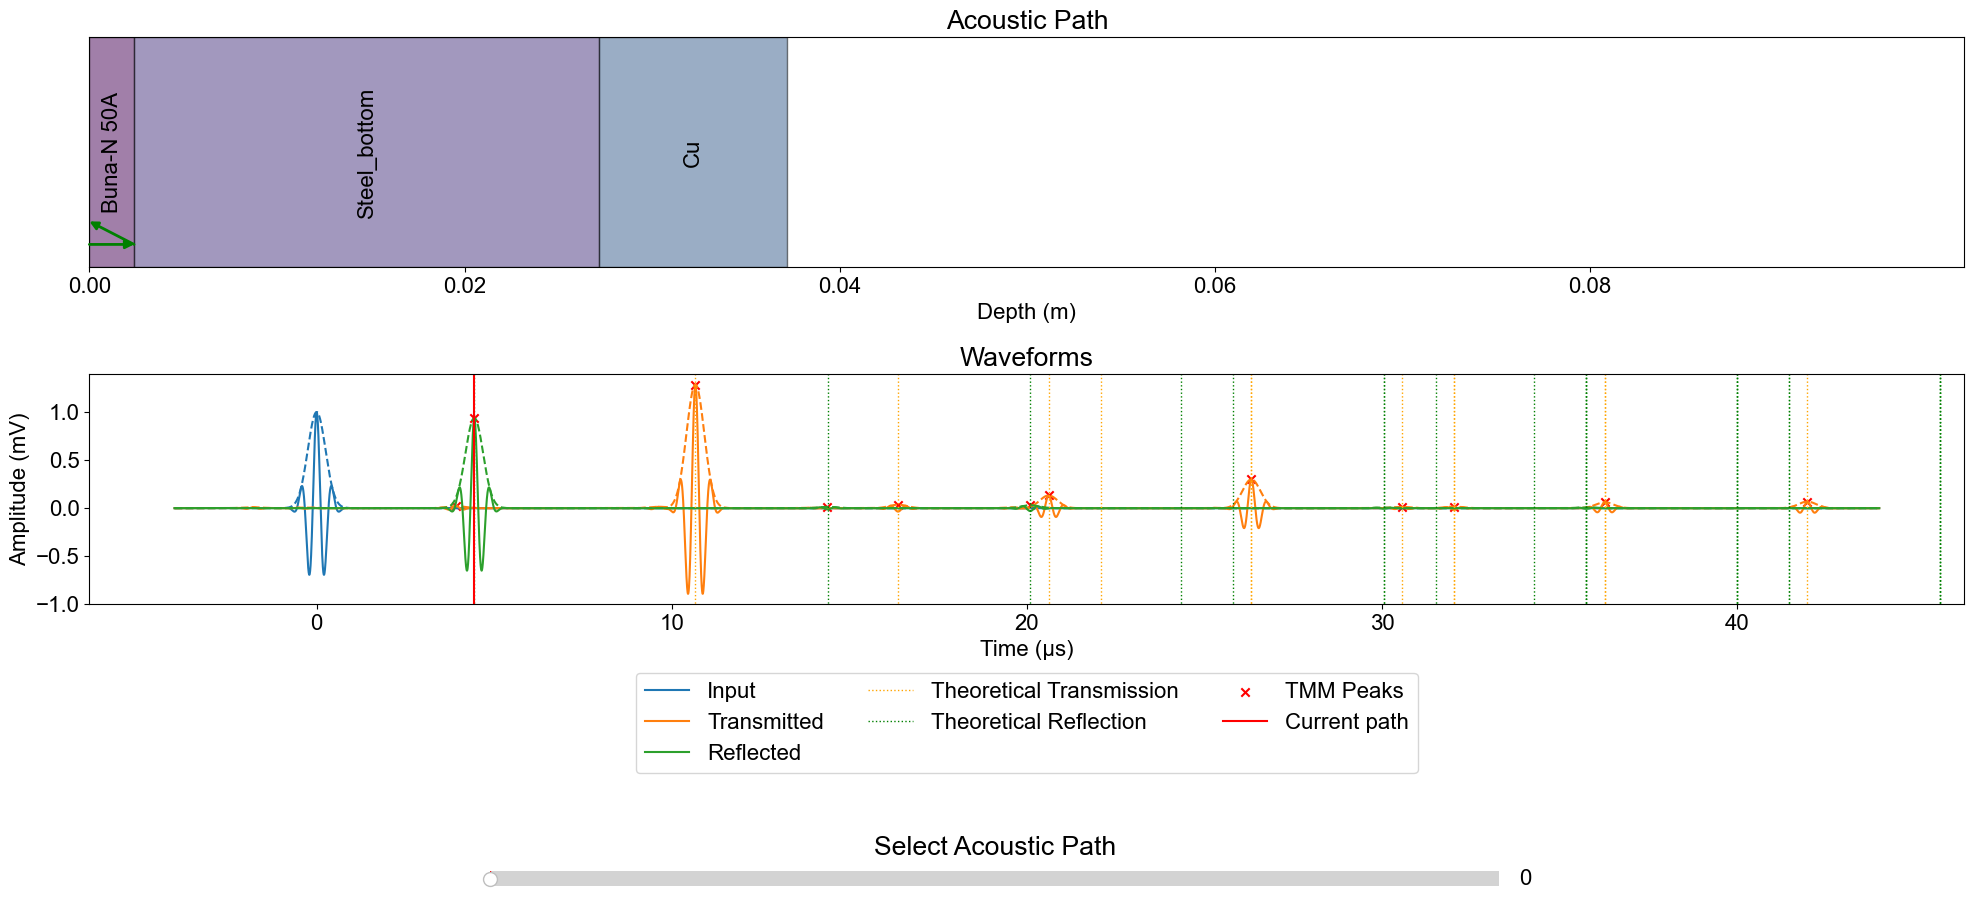

In [ ]:
tmm.plot_path_waveforms_theoretical_v_tmm_time_delays(layers_df, paths, t, 
                                          input_waveform, transmitted_waveform, reflected_waveform, 
                                          input_envelope, transmitted_envelope, reflected_envelope,
                                          layers=list(current_layers_df.index))

##### Take a look at the amplitudes of the waveforms. We are assuming 0 attenuation at the moment.

In [56]:
tmm.compare_tmm_waveform_coefficients(input_waveform, transmitted_waveform, reflected_waveform, layers, dt)

,calculate from,transmission coefficient,reflection coefficient,total
0,TMM,1.7716,0.8806,2.6522
1,Waveforms,1.7711,0.8806,2.6518


### 4 layers (40000 sampling points)

In [57]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-2000,40000+2000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))

In [58]:
current_layers_df = layers_df.iloc[:4]
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form
    
transmitted_waveform = tmm.propagate_waveform(input_waveform, dt, layers) 
transmitted_envelope = abs(signal.hilbert(transmitted_waveform))

reflected_waveform = tmm.reflect_waveform(input_waveform, dt, layers)
reflected_envelope = abs(signal.hilbert(reflected_waveform))

##### Take a look at the time delays in the transmitted waveform. 

In [63]:
# dfs style algorithm to generate all valid reflection and transmission paths up to a specified order
# first and last are not included in layer list because there are no interfaces
# Odd orders yield more reflection paths, even orders are transmission paths
paths = tmm.generate_acoustic_paths(num_layers=len(list(current_layers_df.index)), max_order=7)
paths.sort(key=lambda x: tmm.theoretical_path_time(x, layers_df))

In [64]:
# tmm.print_paths(paths, return_paths=False)

In [65]:
tmm.compare_peak_times(t, layers_df, 
                       transmitted_envelope, reflected_envelope, 
                       paths)

Transmitted tof: (TMM peaks,	theoretical)
	0:	(1.0664e-05,	1.0664e-05)
	1:	(1.6372e-05,	1.6372e-05)
	2:	(2.0612e-05,	2.0612e-05)
	3:	(2.6320e-05,	2.2080e-05)
	4:	(3.0562e-05,	2.6320e-05)
	5:	(3.2026e-05,	2.7788e-05)
	6:	(3.6268e-05,	3.0560e-05)
	7:	(4.1976e-05,	3.2028e-05)
	8:	(5.1924e-05,	3.6268e-05)
	9:	(5.7632e-05,	3.7736e-05)
Reflected tof: (TMM peaks,	theoretical)
	0:	(4.4380e-06,	4.4388e-06)
	1:	(1.4384e-05,	1.4387e-05)
	2:	(2.0094e-05,	2.0095e-05)


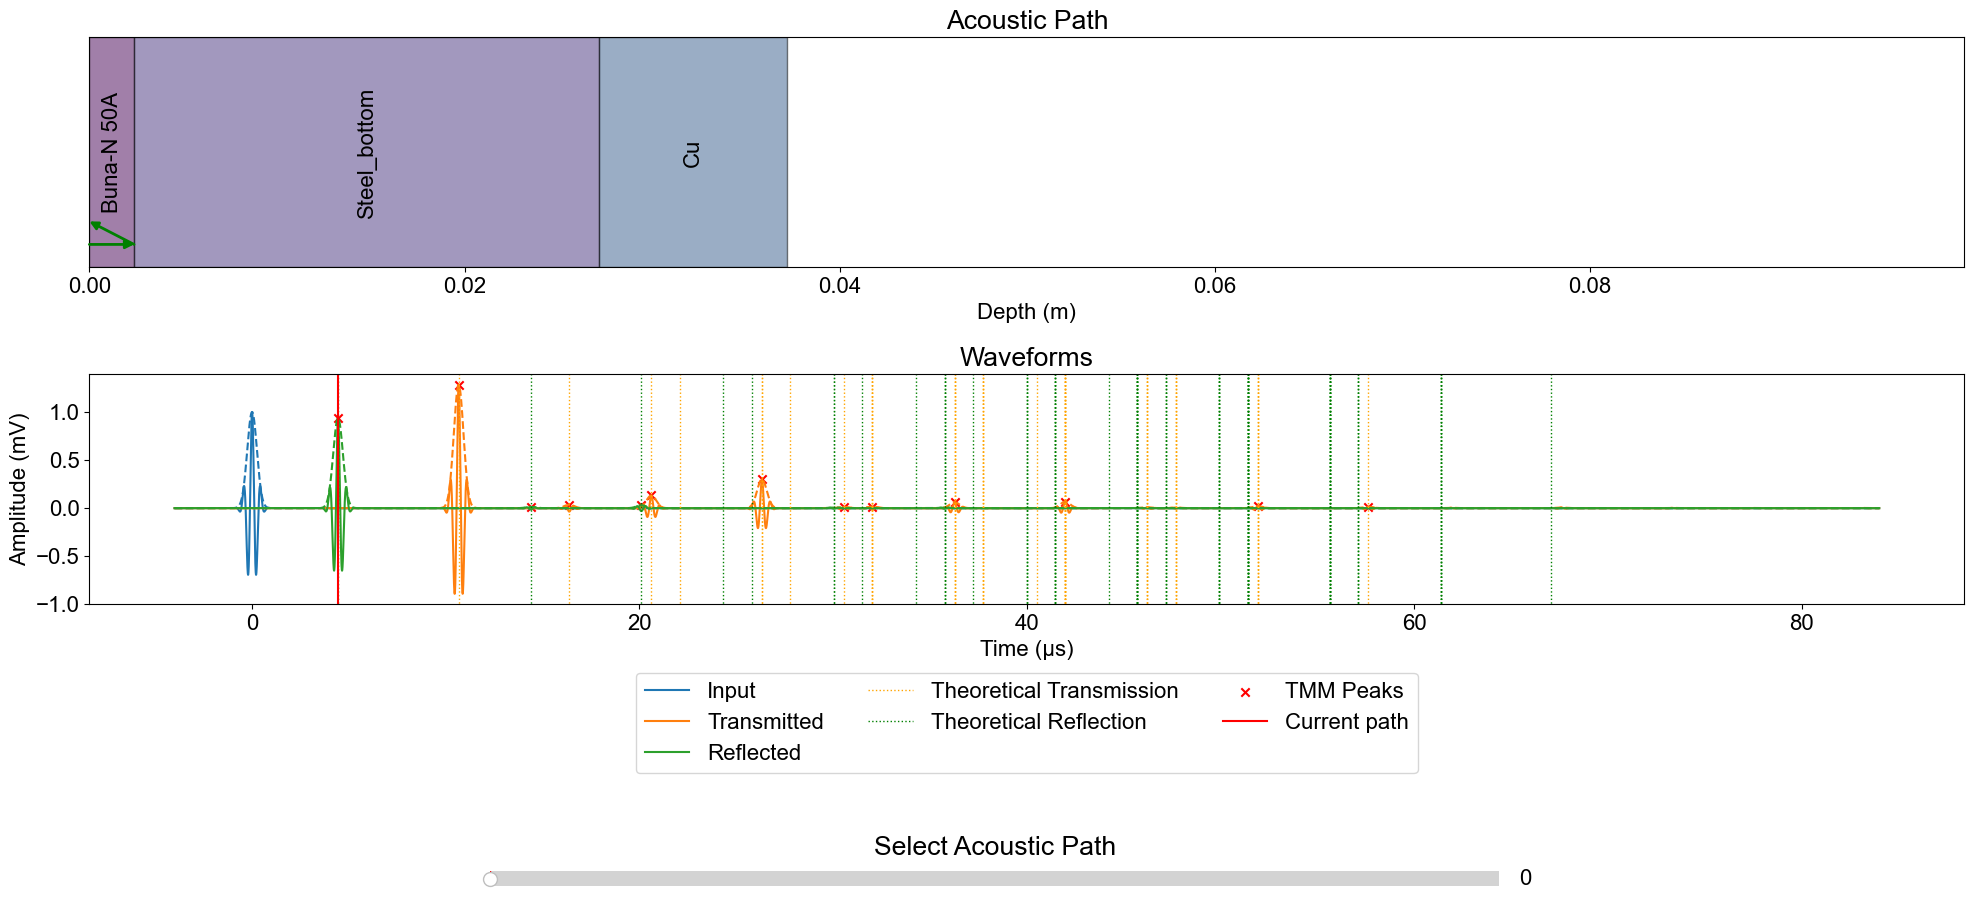

In [ ]:
tmm.plot_path_waveforms_theoretical_v_tmm_time_delays(layers_df, paths, t, 
                                          input_waveform, transmitted_waveform, reflected_waveform, 
                                          input_envelope, transmitted_envelope, reflected_envelope,
                                          layers=list(current_layers_df.index))

##### Take a look at the amplitudes of the waveforms. We are assuming 0 attenuation at the moment.

In [67]:
tmm.compare_tmm_waveform_coefficients(input_waveform, transmitted_waveform, reflected_waveform, layers, dt)

,calculate from,transmission coefficient,reflection coefficient,total
0,TMM,1.7715,0.8806,2.6521
1,Waveforms,1.7703,0.8807,2.6510


### 5 layers (full stack)

In [13]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-1000,20000+1000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))

In [14]:
current_layers_df = layers_df
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form
    
transmitted_waveform = np.real(tmm.propagate_waveform(input_waveform, dt, layers) )
transmitted_envelope = abs(signal.hilbert(transmitted_waveform))

reflected_waveform = np.real(tmm.reflect_waveform(input_waveform, dt, layers))
reflected_envelope = abs(signal.hilbert(reflected_waveform))

##### Take a look at the time delays in the transmitted waveform. 

In [ ]:
# dfs style algorithm to generate all valid reflection and transmission paths up to a specified order
# first and last are not included in layer list because there are no interfaces
# Odd orders yield more reflection paths, even orders are transmission paths
paths = tmm.generate_acoustic_paths(num_layers=len(list(current_layers_df.index)), max_order=5)
paths.sort(key=lambda x: tmm.theoretical_path_time(x, layers_df))
print('calculated paths:', len(paths))

generate_acoustic_paths took 0.0006 seconds


In [34]:
# tmm.print_paths(paths, return_paths=False)

In [35]:
# tmm.compare_peak_times(t, layers_df, 
#                        transmitted_envelope, reflected_envelope, 
#                        paths)

In [49]:
%matplotlib tk
# %matplotlib inline
tmm.plot_path_waveforms_theoretical_v_tmm_time_delays(layers_df, paths, t, 
                                          input_waveform, transmitted_waveform, reflected_waveform, 
                                          input_envelope, transmitted_envelope, reflected_envelope,
                                          layers=list(current_layers_df.index))
                                          

##### Take a look at the amplitudes of the waveforms. We are assuming 0 attenuation at the moment.

In [152]:
tmm.compare_tmm_waveform_coefficients(input_waveform, transmitted_waveform, reflected_waveform, layers, dt)

,calculate from,transmission coefficient,reflection coefficient,total
0,TMM,0.0435,0.9565,1.0000
1,Waveforms,0.0429,0.9571,1.0000


## Make some nice figures

#### adding layers comparison

100%|██████████| 6/6 [00:14<00:00,  2.35s/it]


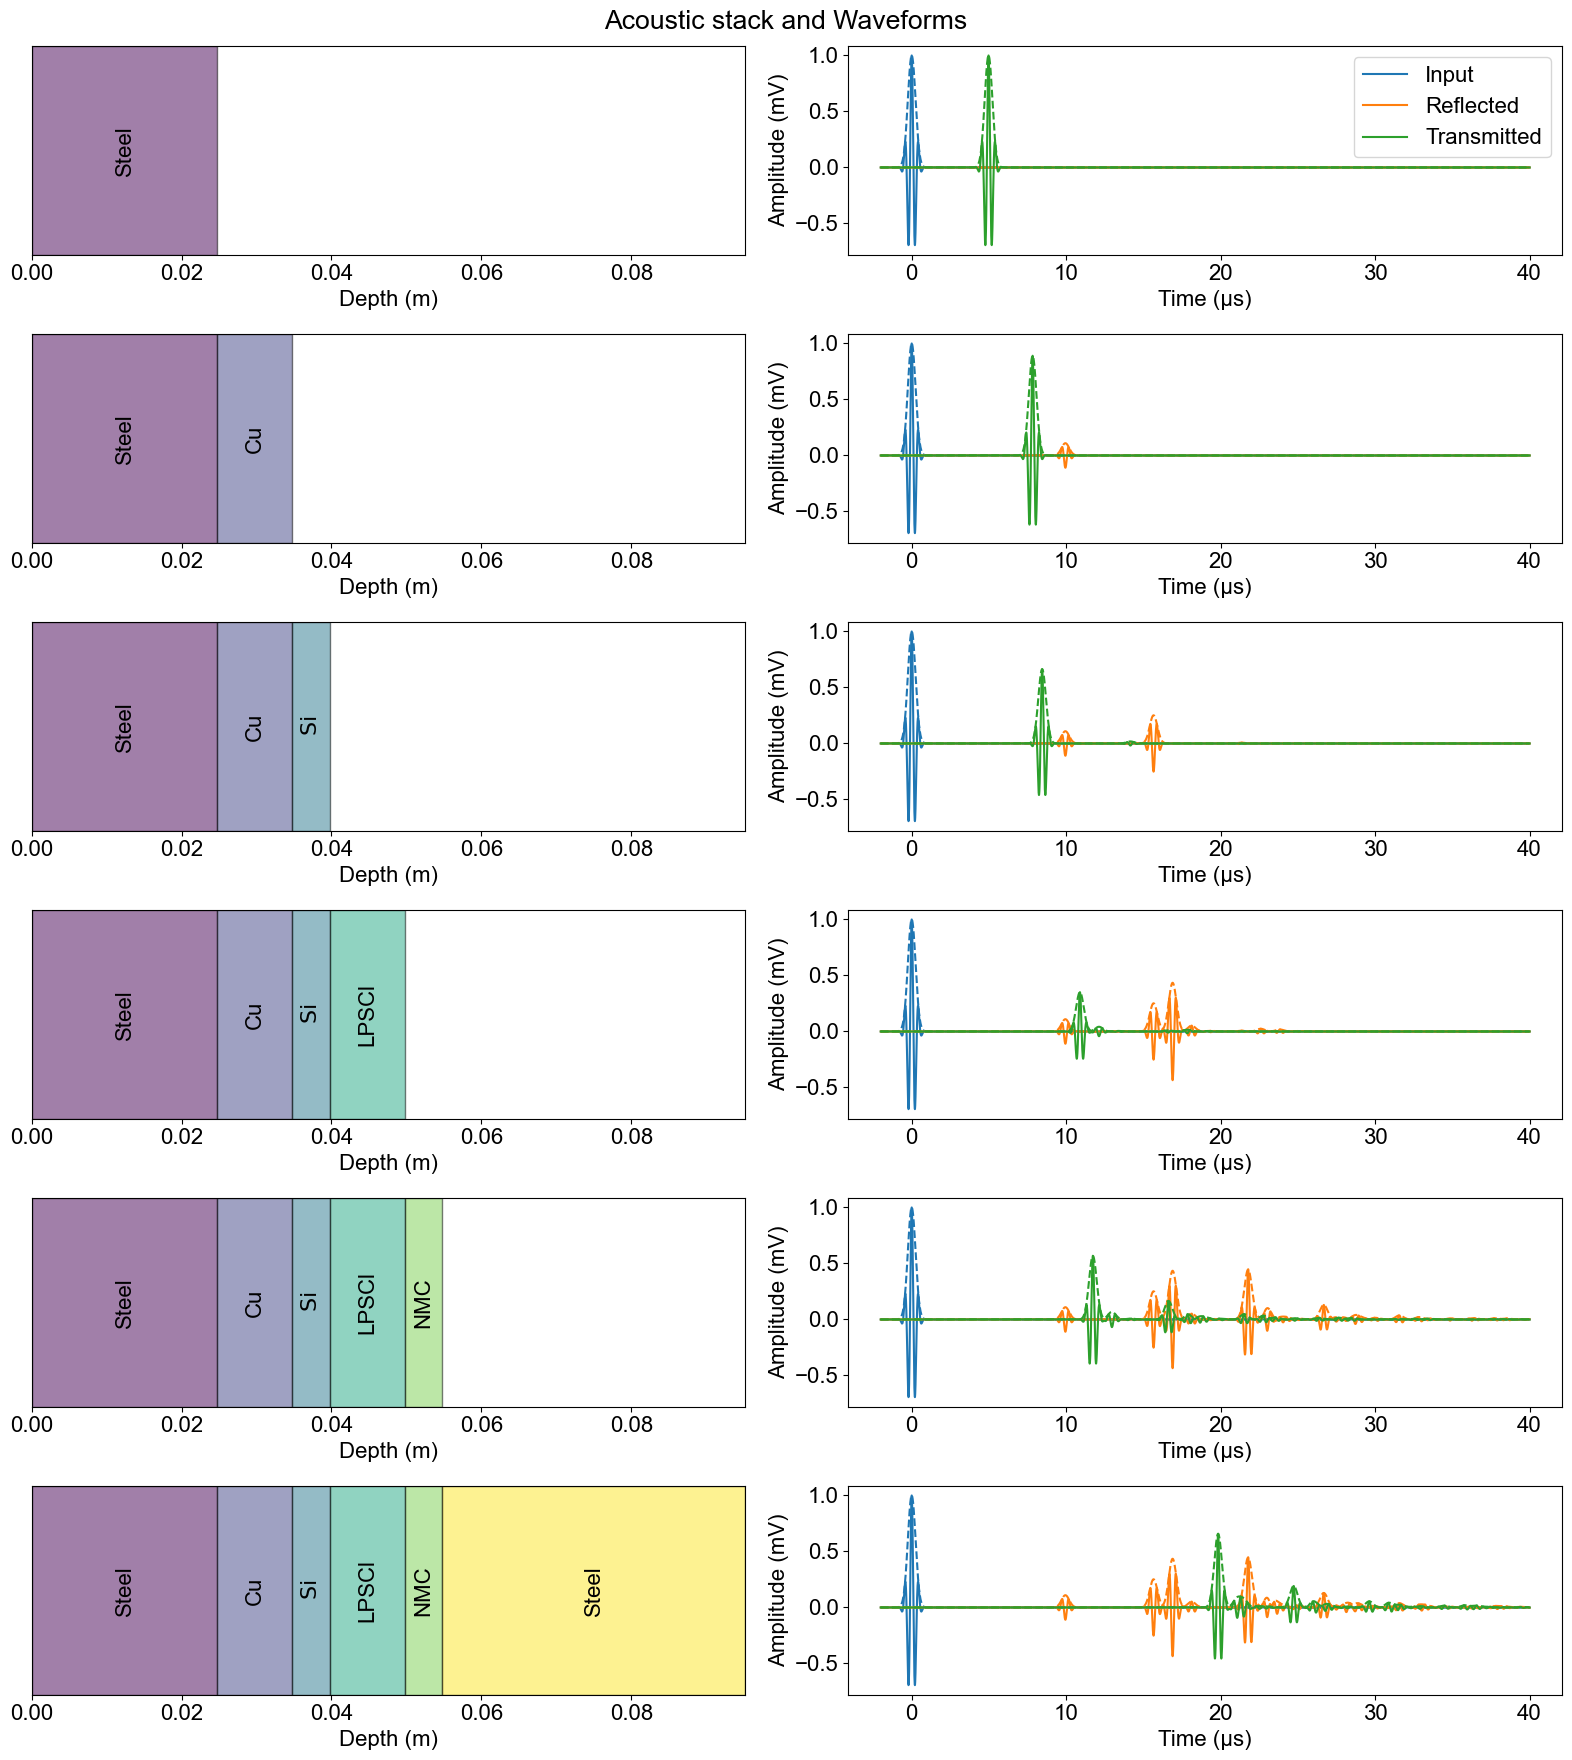

In [19]:
%matplotlib inline

fig, ax = plt.subplots(len(layers_df), 2, figsize=(16, 18))
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-1000,40000-1000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))

crop = slice(0,21000)

for i in tqdm(range(len(layers_df))):
    ax[i,0] = tmm.plot_layers(layers_df, ax=ax[i,0], show_layers=list(range(i+1)), aspect_scale=4, title=None)
    
    current_layers_df = layers_df.iloc[:i+1]
    layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form   
    transmitted_waveform = np.real(tmm.propagate_waveform(input_waveform, dt, layers)) 
    transmitted_envelope = abs(scipy.signal.hilbert(transmitted_waveform))
    reflected_waveform = np.real(tmm.reflect_waveform(input_waveform, dt, layers))
    reflected_envelope = abs(scipy.signal.hilbert(reflected_waveform))
        
    ax[i,1] = tmm.plot_waveforms(t[crop], 
                                 [input_waveform[crop], reflected_waveform[crop], transmitted_waveform[crop]], 
                                 envelopes=[input_envelope[crop], reflected_envelope[crop], transmitted_envelope[crop]], 
                                 labels=['Input', 'Reflected', 'Transmitted'] if i==0 else None,
                                 ax=ax[i,1], title=None)
    # ax[i, 0].annotate('', xy=(3, 0.5), xytext=(0, 0.5),
    #     arrowprops=dict(arrowstyle='->', color=ax[i, 1].lines[0].get_color(), linewidth=2)
    # )
fig.suptitle('Acoustic stack and Waveforms')
fig.tight_layout()

#### make gif of all paths

In [16]:
%matplotlib inline
tmm.save_plot_path_waveforms_gif(layers_df, paths, t, 
                                input_waveform, transmitted_waveform, reflected_waveform, 
                                input_envelope, transmitted_envelope, reflected_envelope,
                                './stack_waveforms_order5.gif',fps=15)

'./stack_waveforms_order5.gif'